<a href="https://colab.research.google.com/github/Kalyani325/AI-RISK/blob/main/Risk_Awareness_of_AI_on_Public_Opnion_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project: A Data Science Framework for Risk-Aware and Responsible AI Usage
Student: Kalyani Thagdam | ID: 24094993

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    StandardScaler, OrdinalEncoder, LabelEncoder
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import shap
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Load Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/gpo-ai_data.csv")
original_df = df.copy()
print("Original Dataset Shape:", df.shape)


Original Dataset Shape: (23781, 324)


In [ ]:
df.head(5)

,Unnamed: 0,respondent_survey_seconds,respondent_survey_data,respondent_yob,respondent_country,respondent_income,respondent_pid,respondent_subnational,respondent_gender,respondent_education,...,aipi5,aipi6,attention_1,attention_2,attention_3,attention_4,attention_5,attention_6,sm,respondent_language
0,1,617,2023-10-23 12:21:06,23,Spain,20000,Partido Socialista Obrero Español (PSOE),Centro (Central),A woman,Bachelor or equivalent,...,Agree.,Concerned.,NaN,NaN,NaN,NaN,NaN,NaN,Yes,ES-ES
1,2,1305,2023-10-23 12:33:05,36,South Africa,450000,Freedom Front Plus,Western Cape,A man,Bachelor or equivalent,...,Agree.,Concerned.,NaN,NaN,NaN,NaN,NaN,NaN,Yes,EN
2,3,913,2023-10-23 12:33:09,30,Italy,30000,Movimento 5 Stelle (M5S),Campania,A woman,Upper secondary education,...,Disagree.,Not at all concerned.,NaN,NaN,NaN,NaN,NaN,NaN,Yes,IT
3,4,1281,2023-10-23 12:33:14,29,India,2400000,Bharatiya Janata Party,Gujarat,A woman,Master or equivalent,...,Disagree.,Concerned.,NaN,NaN,NaN,NaN,NaN,NaN,Yes,EN
4,5,1290,2023-10-23 12:35:16,23,Brazil,45000,Partido dos Trabalhadores,Minas Gerais,A man,Post-secondary education,...,Agree.,Concerned.,NaN,NaN,NaN,NaN,NaN,NaN,Yes,PT-BR


Data Preprocessing

In [ ]:
 #Drop unnamed index column
df.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)


In [ ]:
# Drop attention check columns
attention_cols = [col for col in df.columns if "attention" in col.lower()]
df.drop(columns=attention_cols, inplace=True)
print("After removing attention columns:", df.shape)

After removing attention columns: (23781, 317)


In [ ]:
# Check missing values before cleaning
missing_before = df.isnull().sum().sum()
print("Total Missing Values BEFORE:", missing_before)

Total Missing Values BEFORE: 2553147


In [ ]:
# Remove columns with more than 50% missing values
missing_percent = df.isnull().mean()
cols_to_drop = missing_percent[missing_percent > 0.5].index
df.drop(columns=cols_to_drop, inplace=True)
print("Columns removed (>50% missing):", len(cols_to_drop))
print("Shape after removing high-missing columns:", df.shape)

Columns removed (>50% missing): 125
Shape after removing high-missing columns: (23781, 192)


In [ ]:
# Fill numeric columns with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
print("Missing Values AFTER:", df.isnull().sum().sum())
print("Dataset Shape After Cleaning:", df.shape)


Missing Values AFTER: 0
Dataset Shape After Cleaning: (23781, 192)


SAVE CLEANED DATA

In [ ]:
df.to_csv("/content/drive/MyDrive/gpo_ai_cleaned.csv", index=False)
print("Saved: gpo_ai_cleaned.csv —", df.shape)

Saved: gpo_ai_cleaned.csv — (23781, 192)


In [ ]:
df.head(5)

,respondent_survey_seconds,respondent_survey_data,respondent_yob,respondent_country,respondent_income,respondent_pid,respondent_subnational,respondent_gender,respondent_education,children,...,TO_finance,TO_border,aipi1,aipi2,aipi3,aipi4,aipi5,aipi6,sm,respondent_language
0,617,2023-10-23 12:21:06,23,Spain,20000,Partido Socialista Obrero Español (PSOE),Centro (Central),A woman,Bachelor or equivalent,"No, I do not have any children",...,An Artificial Intelligence (AI)-algorithm to m...,A human to decide who to screen more carefully,We should go slowly and deliberately.,Concerned about growth.,Likely.,Agree.,Agree.,Concerned.,Yes,ES-ES
1,1305,2023-10-23 12:33:05,36,South Africa,450000,Freedom Front Plus,Western Cape,A man,Bachelor or equivalent,"Yes, I have children UNDER the age of 18",...,An Artificial Intelligence (AI)-algorithm to m...,An Artificial Intelligence (AI)-algorithm to d...,We should speed up development.,Excited about growth.,Not likely.,Agree.,Agree.,Concerned.,Yes,EN
2,913,2023-10-23 12:33:09,30,Italy,30000,Movimento 5 Stelle (M5S),Campania,A woman,Upper secondary education,"Yes, I have children UNDER the age of 18",...,A human to make the final decision in whether ...,A human to decide who to screen more carefully,We should go slowly and deliberately.,Excited about growth.,Likely.,Agree.,Disagree.,Not at all concerned.,Yes,IT
3,1281,2023-10-23 12:33:14,29,India,2400000,Bharatiya Janata Party,Gujarat,A woman,Master or equivalent,"Yes, I have children UNDER the age of 18",...,A human to make the final decision in whether ...,A human to decide who to screen more carefully,We should go slowly and deliberately.,Excited about growth.,Not likely.,Agree.,Disagree.,Concerned.,Yes,EN
4,1290,2023-10-23 12:35:16,23,Brazil,45000,Partido dos Trabalhadores,Minas Gerais,A man,Post-secondary education,"Yes, I have children UNDER the age of 18",...,A human to make the final decision in whether ...,A human to decide who to screen more carefully,We should go slowly and deliberately.,Excited about growth.,Likely.,Agree.,Agree.,Concerned.,Yes,PT-BR


Continue Preprocessing

In [ ]:
# Remove high-cardinality categorical columns (more than 30 unique values)
high_cardinality = [col for col in cat_cols if df[col].nunique() > 30]
df.drop(columns=high_cardinality, inplace=True)
print("Removed high-cardinality columns:", len(high_cardinality))

Removed high-cardinality columns: 9


In [ ]:
# One-hot encode all categorical columns
df_enhanced = pd.get_dummies(df, drop_first=True)
print("Encoded Shape:", df_enhanced.shape)
print("Final Missing Values:", df_enhanced.isnull().sum().sum())

Encoded Shape: (23781, 540)
Final Missing Values: 0


In [ ]:
# Save the one-hot encoded ML-ready DataFrame
df_enhanced.to_csv("/content/drive/MyDrive/gpo_ai_encoded.csv", index=False)
print("Saved: gpo_ai_encoded.csv —", df_enhanced.shape)

Saved: gpo_ai_encoded.csv — (23781, 540)


In [ ]:
# Apply Variance Threshold to remove near-zero-variance features
selector = VarianceThreshold(threshold=0.01)
df_features = df_enhanced.drop(columns=['Risk_Group', 'Risk_Label'], errors='ignore')
df_final_array = selector.fit_transform(df_features)
print("Final Dataset Shape after VarianceThreshold:", df_final_array.shape)

Final Dataset Shape after VarianceThreshold: (23781, 538)


In [ ]:
# Scale the full enhanced dataset
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(df_enhanced)

# Convert filtered array to DataFrame
df_final = pd.DataFrame(df_final_array)

In [ ]:
df_final.head(5)

,0,1,2,3,4,5,6,7,8,9,...,528,529,530,531,532,533,534,535,536,537
0,617.0,23.0,2.0,6.0,6.0,6.0,8.0,9.0,7.0,3.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1305.0,36.0,6.0,0.0,2.0,2.0,3.0,1.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,913.0,30.0,5.0,5.0,5.0,6.0,7.0,7.0,10.0,5.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1281.0,29.0,8.0,9.0,9.0,10.0,9.0,9.0,10.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1290.0,23.0,0.0,3.0,6.0,3.0,7.0,7.0,8.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df_final.shape

(23781, 538)

Exploratory Data Analysis

In [ ]:
# Dataset overview
print("Dataset Shape:", df_enhanced.shape)
df_enhanced.info()
print(df_enhanced.describe())

Dataset Shape: (23781, 540)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23781 entries, 0 to 23780
Columns: 540 entries, respondent_survey_seconds to respondent_language_ZH-S
dtypes: bool(503), float64(35), int64(2)
memory usage: 18.1 MB
       respondent_survey_seconds  respondent_yob    Ideology_1    trust_AI_1  \
count               23781.000000    23781.000000  23781.000000  23781.000000   
mean                 2722.795803       41.161473      5.620285      5.427022   
std                 10032.358208       14.497669      2.460155      2.810878   
min                   333.000000       18.000000      0.000000      0.000000   
25%                  1206.000000       29.000000      5.000000      3.000000   
50%                  1766.000000       40.000000      5.000000      6.000000   
75%                  2598.000000       52.000000      7.000000      7.000000   
max                754651.000000       99.000000     10.000000     10.000000   

         trust_AI_2    trust_AI_3   

In [ ]:
# Print column names
print(df.columns)


Index(['respondent_survey_seconds', 'respondent_yob', 'respondent_country',
       'children', 'children_nb', 'subjective_income', 'urban',
       'partner_employed', 'union_household', 'isco_top',
       ...
       'TO_finance', 'TO_border', 'aipi1', 'aipi2', 'aipi3', 'aipi4', 'aipi5',
       'aipi6', 'sm', 'respondent_language'],
      dtype='object', length=183)


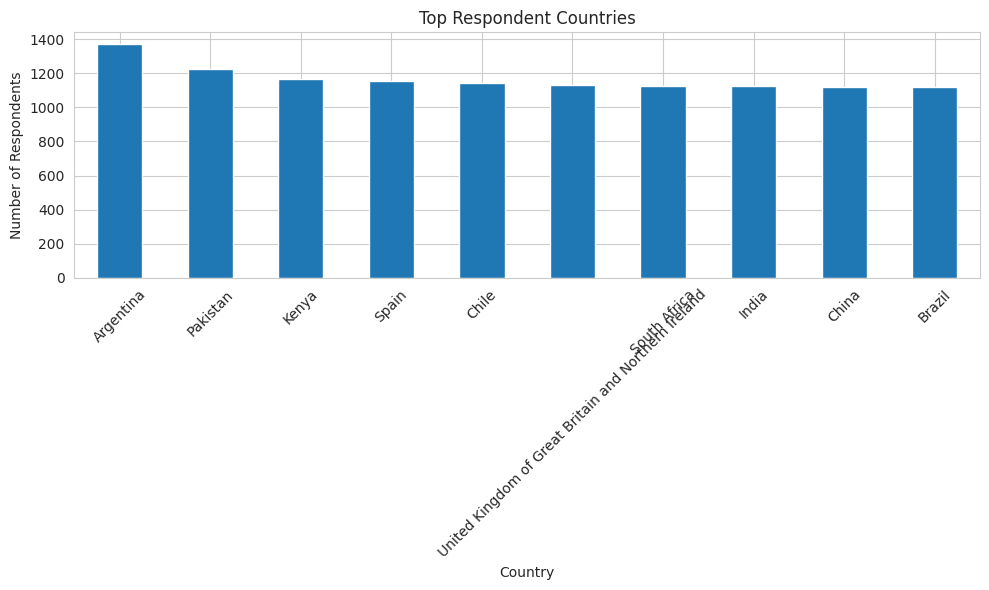

In [ ]:
# Top 10 Respondent Countries
plt.figure(figsize=(10, 6))
df['respondent_country'].value_counts().head(10).plot(kind='bar')
plt.title("Top Respondent Countries")
plt.xlabel("Country")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


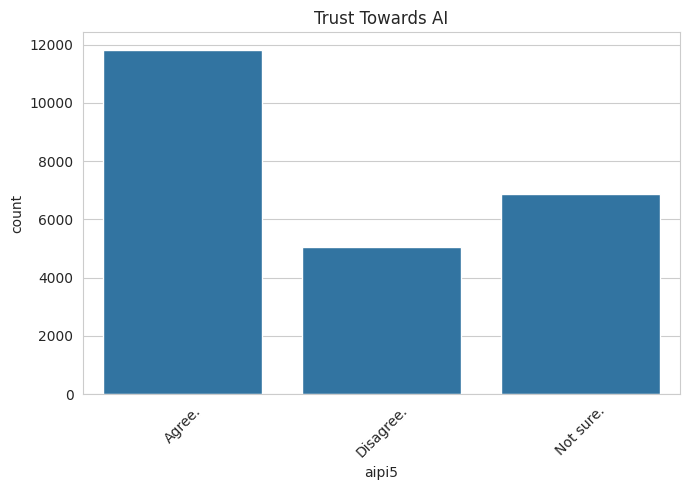

In [ ]:
# AI Concern / Trust Distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='aipi5', data=df)
plt.title("Trust Towards AI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

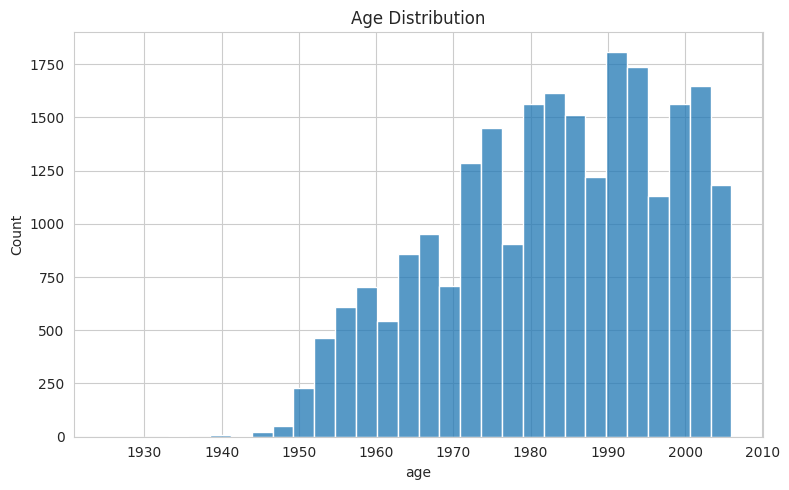

In [ ]:
# Age Distribution
df['age'] = 2024 - df['respondent_yob']
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=30)
plt.title("Age Distribution")
plt.tight_layout()
plt.show()

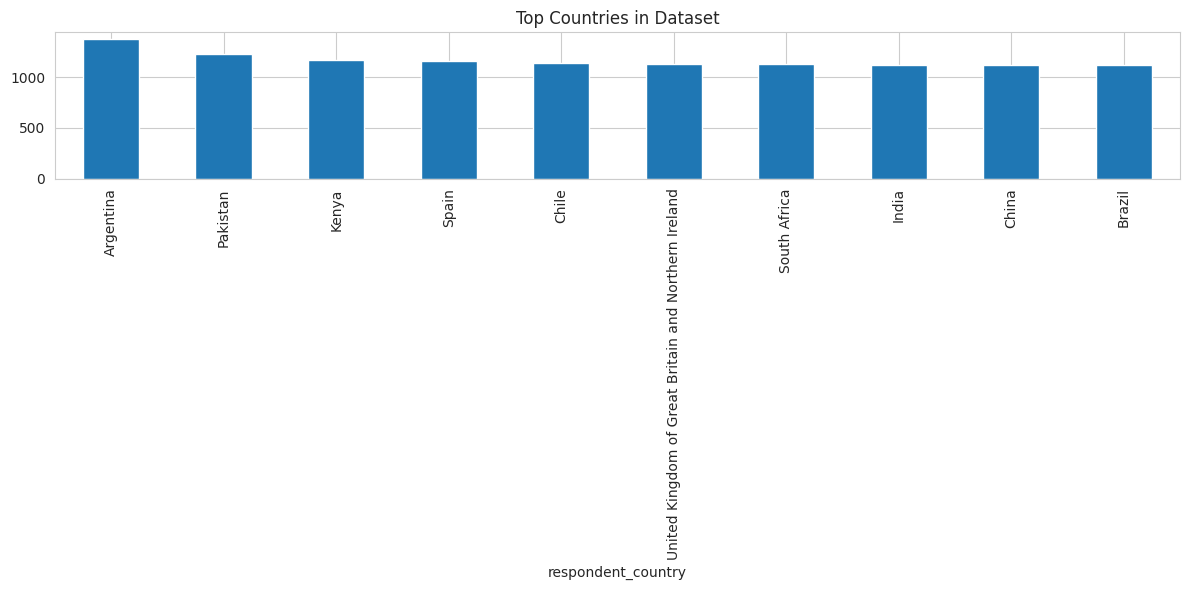

In [ ]:
# Top Countries in Dataset
plt.figure(figsize=(12, 6))
df['respondent_country'].value_counts().head(10).plot(kind='bar')
plt.title("Top Countries in Dataset")
plt.tight_layout()
plt.show()


CREATE AI RISK SCORE

In [ ]:
risk_cols = ['aipi1', 'aipi2', 'aipi3', 'aipi4', 'aipi5', 'aipi6']

# Initial risk mapping (for distribution plot)
risk_map_initial = {
    "Strongly agree.": 3,
    "Agree.": 2,
    "Neutral.": 1,
    "Disagree.": 0,
    "Strongly disagree.": 0,
    "Concerned.": 3,
    "Not at all concerned.": 0
}

for col in risk_cols:
    df[col + "_score"] = df[col].map(risk_map_initial)

df['AI_Risk_Score'] = df[[c + "_score" for c in risk_cols]].mean(axis=1)

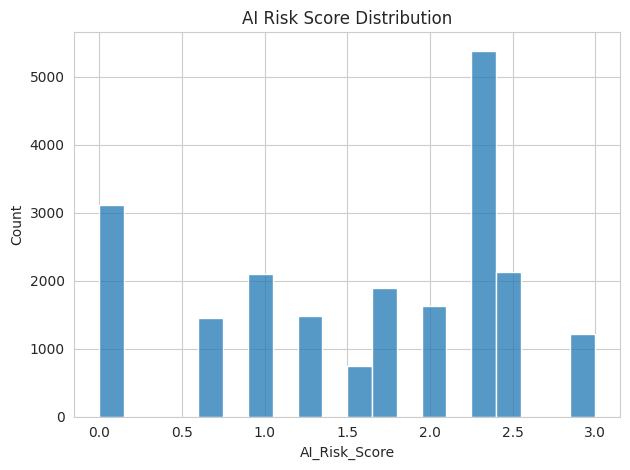

In [ ]:
# Plot AI Risk Score Distribution
sns.histplot(df['AI_Risk_Score'], bins=20)
plt.title("AI Risk Score Distribution")
plt.tight_layout()
plt.show()

In [ ]:
# Check NaN counts per score column
score_cols = [c + "_score" for c in risk_cols]
print(df[score_cols].isnull().sum())

aipi1_score    23781
aipi2_score    23781
aipi3_score    23781
aipi4_score     8084
aipi5_score     6886
aipi6_score     5371
dtype: int64


CLUSTERING (K-MEANS)

In [ ]:
# Updated risk map (covers all response values)
risk_map = {
    "Strongly agree.": 3,
    "Agree.": 2,
    "Neutral.": 1,
    "Disagree.": 0,
    "Strongly disagree.": 0,
    "Concerned.": 3,
    "Somewhat concerned.": 2,
    "Not very concerned.": 1,
    "Not at all concerned.": 0
}

In [ ]:
# Fill missing risk columns with "Neutral." before encoding
df[risk_cols] = df[risk_cols].fillna("Neutral.")

In [ ]:
# Encode text responses to numbers using OrdinalEncoder
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df[risk_cols] = encoder.fit_transform(df[risk_cols])

# Replace unknown encodings (-1) with column medians
df[risk_cols] = df[risk_cols].replace(-1, df[risk_cols].median())

# Final NaN check
print("Remaining Missing Values:", df[risk_cols].isnull().sum().sum())


Remaining Missing Values: 0


In [ ]:
# Prepare Feature Matrix and scale
X_cluster = df[risk_cols]
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)

Elbow Method

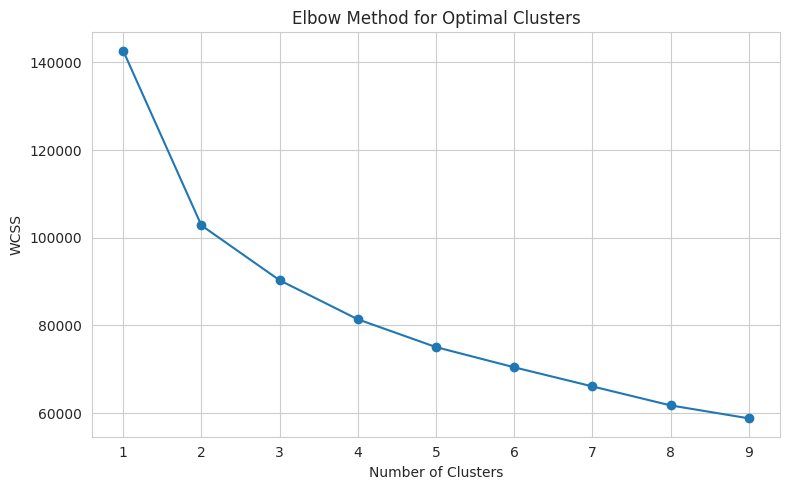

In [ ]:
# Elbow Method to Find Optimal K
wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), wcss, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.tight_layout()
plt.show()


In [ ]:
# Fit Final K-Means (k=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_enhanced['Cluster'] = clusters
df['Risk_Cluster'] = clusters

print(df['Risk_Cluster'].value_counts())


Risk_Cluster
0    8616
3    5800
2    5052
1    4313
Name: count, dtype: int64


In [ ]:
# Cluster Profiling
cluster_profile = df.groupby('Risk_Cluster')[risk_cols].mean()
print(cluster_profile)


                 aipi1     aipi2     aipi3     aipi4     aipi5     aipi6
Risk_Cluster                                                            
0             1.188487  0.506732  0.236537  0.096565  0.242224  0.173398
1             0.469511  1.663343  1.652910  1.763506  1.647113  1.575470
2             0.880839  0.305819  0.799287  1.723476  0.872130  0.427751
3             1.624310  0.804655  1.160000  0.635000  0.903276  1.139310


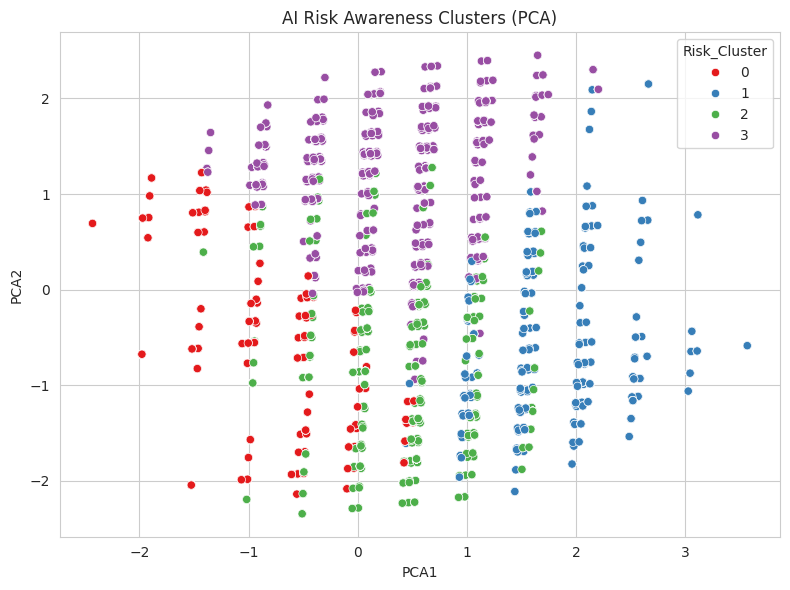

In [ ]:
# PCA Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Risk_Cluster', palette='Set1', data=df)
plt.title("AI Risk Awareness Clusters (PCA)")
plt.tight_layout()
plt.show()

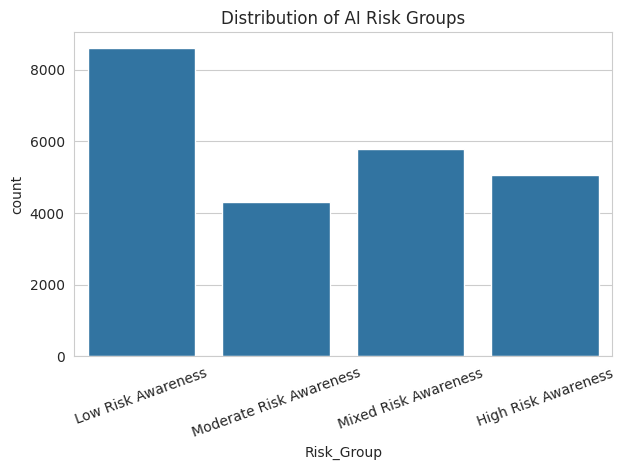

In [ ]:
# Name the Clusters
cluster_names = {
    0: "Low Risk Awareness",
    1: "Moderate Risk Awareness",
    2: "High Risk Awareness",
    3: "Mixed Risk Awareness"
}
df['Risk_Group'] = df['Risk_Cluster'].map(cluster_names)

sns.countplot(x='Risk_Group', data=df)
plt.title("Distribution of AI Risk Groups")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
print(df['Risk_Group'].value_counts())

Risk_Group
Low Risk Awareness         8616
Mixed Risk Awareness       5800
High Risk Awareness        5052
Moderate Risk Awareness    4313
Name: count, dtype: int64


In [ ]:
# Add cluster labels to ML dataset
df_enhanced['Risk_Group'] = df['Risk_Group']


In [ ]:
# Encode target variable
le = LabelEncoder()
df_enhanced['Risk_Label'] = le.fit_transform(df_enhanced['Risk_Group'])

In [ ]:
# Save final labelled dataset
df_enhanced.to_csv("/content/drive/MyDrive/gpo_ai_clustered.csv", index=False)
print("Saved: gpo_ai_clustered.csv —", df_enhanced.shape)

Saved: gpo_ai_clustered.csv — (23781, 543)


Random Forest Classifier

In [ ]:
# Remove leakage features (same columns used to build cluster labels)
leakage_features = ['aipi1', 'aipi2', 'aipi3', 'aipi4', 'aipi5', 'aipi6']

X_rf = df_enhanced.drop(
    columns=['Cluster', 'Risk_Group', 'Risk_Label'] + leakage_features,
    errors='ignore'
)
y_rf = df_enhanced['Cluster']

In [ ]:
# Fill any remaining NaNs
X_rf.fillna(X_rf.median(), inplace=True)

In [ ]:
# Train/Test Split
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
rf.fit(X_train_rf, y_train_rf)
y_pred_rf = rf.predict(X_test_rf)
print("Random Forest Accuracy:", accuracy_score(y_test_rf, y_pred_rf))


Random Forest Accuracy: 0.8578936304393525


In [ ]:
# Cross-Validation Score
scores = cross_val_score(rf, X_rf, y_rf, cv=5)
print("CV Accuracy:", scores.mean())

CV Accuracy: 0.8574915316687036


LOGISTIC REGRESSION CLASSIFIER

In [ ]:
# Remove all one-hot encoded columns derived from risk base columns
cluster_features_base = ['aipi1', 'aipi2', 'aipi3', 'aipi4', 'aipi5', 'aipi6']
cluster_features_to_remove = [
    col for col in df_enhanced.columns
    if any(base_col in col for base_col in cluster_features_base)
]

X_lr = df_enhanced.drop(
    columns=['Cluster', 'Risk_Group', 'Risk_Label'] + cluster_features_to_remove,
    errors='ignore'
)
y_lr = df_enhanced['Cluster']

In [ ]:
# Fill any remaining NaNs
X_lr.fillna(X_lr.median(), inplace=True)


In [ ]:
# Train/Test Split (stratified)
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr,
    test_size=0.2,
    random_state=42,
    stratify=y_lr
)

In [ ]:
# Scale
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train_lr)
X_test_scaled = scaler_lr.transform(X_test_lr)

In [ ]:
# Replace any leftover NaNs/Infs with 0
X_train_scaled = np.nan_to_num(X_train_scaled)
X_test_scaled = np.nan_to_num(X_test_scaled)


In [ ]:
# Train Logistic Regression
log_reg = LogisticRegression(max_iter=2000, multi_class='multinomial')
log_reg.fit(X_train_scaled, y_train_lr)

y_pred_lr = log_reg.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test_lr, y_pred_lr))
print(classification_report(y_test_lr, y_pred_lr))


Logistic Regression Accuracy: 0.4994744586924532
              precision    recall  f1-score   support

           0       0.56      0.67      0.61      1723
           1       0.52      0.51      0.51       863
           2       0.38      0.29      0.33      1011
           3       0.45      0.41      0.43      1160

    accuracy                           0.50      4757
   macro avg       0.48      0.47      0.47      4757
weighted avg       0.49      0.50      0.49      4757



FEATURE IMPORTANCE

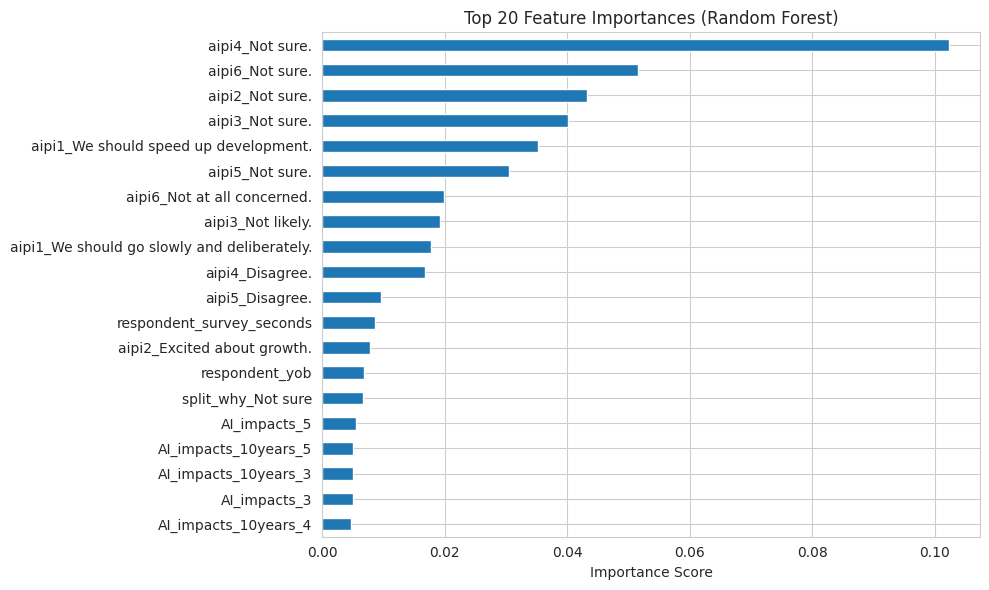

In [ ]:
#Random Forest Built-in Feature Importance (Instant) ---
importances = pd.Series(rf.feature_importances_, index=X_train_rf.columns)
top_features = importances.sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
top_features.plot(kind='barh')
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Shap

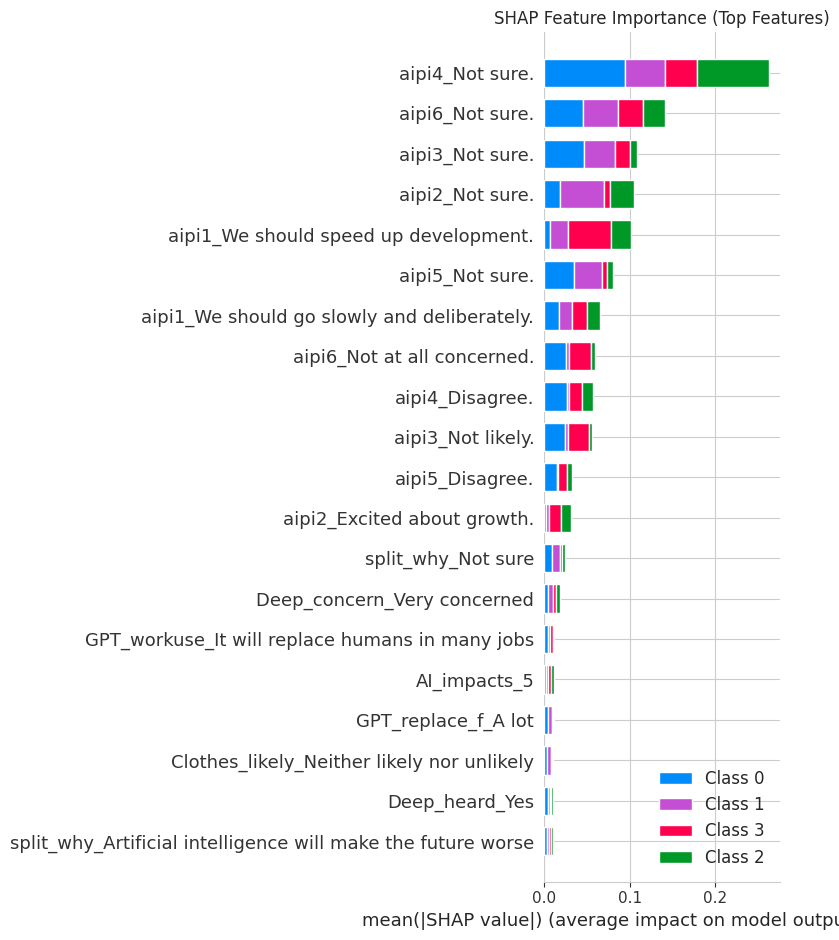

In [ ]:
#Lightweight SHAP (Only 100 rows, much faster) ---
import shap
# Use only 100 rows to keep it fast
X_shap_sample = X_test_rf.iloc[:100]
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap_sample, check_additivity=False)
# Overall bar plot (summarises all clusters)
plt.figure()
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Top Features)")
plt.tight_layout()
plt.show()

 CROSS-VALIDATION

Random Forest Cross-Validation Results
Fold Scores     : [0.8625 0.845  0.8623 0.8553 0.857 ]
Mean Accuracy   : 0.8564
Std Deviation   : 0.0064
Min Accuracy    : 0.8450
Max Accuracy    : 0.8625

Logistic Regression Cross-Validation Results
Fold Scores     : [0.5102 0.5151 0.4987 0.512  0.5118]
Mean Accuracy   : 0.5096
Std Deviation   : 0.0056
Min Accuracy    : 0.4987
Max Accuracy    : 0.5151


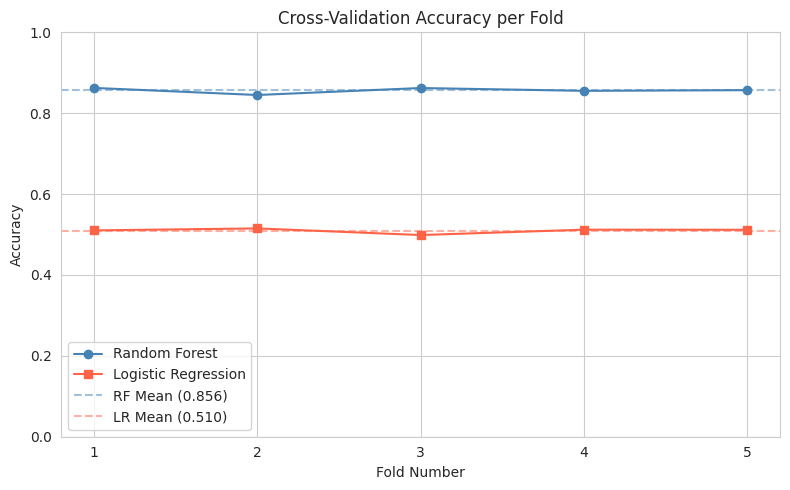


              Model  Mean CV Accuracy  Std Deviation  Min Accuracy  Max Accuracy
      Random Forest            0.8564         0.0064        0.8450        0.8625
Logistic Regression            0.5096         0.0056        0.4987        0.5151


In [ ]:

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score
import numpy as np

# Define 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# --- Random Forest Cross-Validation ---
rf_cv_scores = cross_val_score(
    rf, X_rf, y_rf,
    cv=cv,
    scoring='accuracy'
)

print("=" * 45)
print("Random Forest Cross-Validation Results")
print("=" * 45)
print(f"Fold Scores     : {np.round(rf_cv_scores, 4)}")
print(f"Mean Accuracy   : {rf_cv_scores.mean():.4f}")
print(f"Std Deviation   : {rf_cv_scores.std():.4f}")
print(f"Min Accuracy    : {rf_cv_scores.min():.4f}")
print(f"Max Accuracy    : {rf_cv_scores.max():.4f}")


# --- Logistic Regression Cross-Validation ---
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=2000, multi_class='multinomial'))
])

lr_cv_scores = cross_val_score(
    lr_pipeline, X_lr, y_lr,
    cv=cv,
    scoring='accuracy'
)

print()
print("=" * 45)
print("Logistic Regression Cross-Validation Results")
print("=" * 45)
print(f"Fold Scores     : {np.round(lr_cv_scores, 4)}")
print(f"Mean Accuracy   : {lr_cv_scores.mean():.4f}")
print(f"Std Deviation   : {lr_cv_scores.std():.4f}")
print(f"Min Accuracy    : {lr_cv_scores.min():.4f}")
print(f"Max Accuracy    : {lr_cv_scores.max():.4f}")


# --- Comparison Plot ---
plt.figure(figsize=(8, 5))

plt.plot(range(1, 6), rf_cv_scores, marker='o', label='Random Forest', color='steelblue')
plt.plot(range(1, 6), lr_cv_scores, marker='s', label='Logistic Regression', color='tomato')

plt.axhline(rf_cv_scores.mean(), color='steelblue', linestyle='--', alpha=0.5, label=f'RF Mean ({rf_cv_scores.mean():.3f})')
plt.axhline(lr_cv_scores.mean(), color='tomato',    linestyle='--', alpha=0.5, label=f'LR Mean ({lr_cv_scores.mean():.3f})')

plt.title("Cross-Validation Accuracy per Fold")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.xticks(range(1, 6))
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


# --- Summary Comparison Table ---
summary = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'Mean CV Accuracy': [rf_cv_scores.mean(), lr_cv_scores.mean()],
    'Std Deviation':    [rf_cv_scores.std(),  lr_cv_scores.std()],
    'Min Accuracy':     [rf_cv_scores.min(),  lr_cv_scores.min()],
    'Max Accuracy':     [rf_cv_scores.max(),  lr_cv_scores.max()]
})
summary = summary.round(4)
print()
print(summary.to_string(index=False))